In [9]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np 
import matplotlib.pyplot as plt
import mne

from mi_decoder.csp import CSP, CSPMulticlass
from mi_decoder.lda import LDA
from mi_decoder.data import load_subject
from mi_decoder.preprocess import epoch_session


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
data = load_subject(1)
X_train, y_train = epoch_session(data['0train'])
X_test,  y_test  = epoch_session(data['1test'])

print(f"Train: X={X_train.shape}, y={y_train.shape}, classes={np.bincount(y_train)}")
print(f"Test:  X={X_test.shape},  y={y_test.shape},  classes={np.bincount(y_test)}")

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: [np.str_('feet'), np.str_('left_hand'), np.str_('right_hand'), np.str_('tongue')]
Not setting metadata
48 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 48 events and 1126 original time points ...
0 bad epochs dropped
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
--

In [5]:
binary_mask_train = (y_train == 0) | (y_train == 1)  # left and right hand
X_bin = X_train[binary_mask_train]
y_bin = y_train[binary_mask_train]

csp = CSP(n_components=3)
csp.fit(X_bin, y_bin)

print("Filter shape:", csp.filters_.shape)  # (6, 22)

Filter shape: (6, 22)


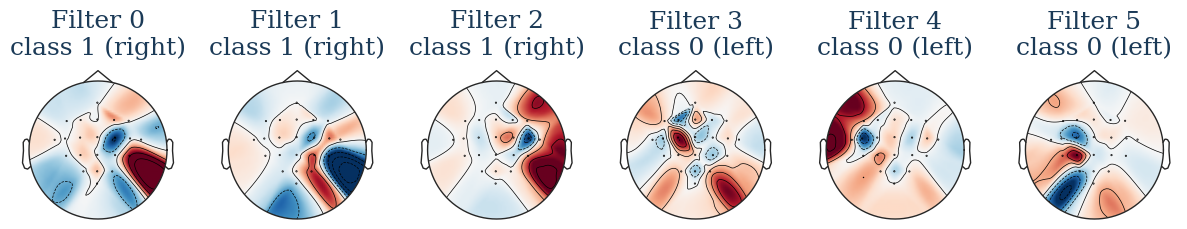

In [6]:
sample_raw = data['0train']['0'].copy().pick(picks='eeg')
sample_raw.set_montage(mne.channels.make_standard_montage('standard_1020'))
info = sample_raw.info


fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i, ax in enumerate(axes):
    mne.viz.plot_topomap(csp.filters_[i], info, axes=ax, show=False, cmap='RdBu_r')
    ax.set_title(f'Filter {i}\n{"class 1 (right)" if i < 3 else "class 0 (left)"}')
plt.show()

In [11]:
csp = CSPMulticlass(n_components=3)
csp.fit(X_train, y_train)
features_train = csp.transform(X_train)
features_test = csp.transform(X_test)

In [13]:
lda = LDA()
lda.fit(features_train, y_train)
y_pred = lda.predict(features_test)
accuracy = np.mean(y_pred == y_test)
print(f"Test Accuracy: {accuracy:.2f}")

Test Accuracy: 0.65


In [ ]:
'''     self.classes_ = None # (K,)
        self.means_ = None # (K, d)
        self.cov_ = None # (d, d) -> d = number of features
        self.priors_ = None # (K,)
        self.W_ = None # (d, K) 
        self.intercepts_ = None # (K,)'''

print(lda.means_.shape)
# print(lda.means_)


(4, 24)
[[-146.78329015 -143.10303792 -141.49185366 -138.93032618]
 [ -95.31126015  -95.26504515  -94.79414439  -89.04599814]
 [ -81.57481841  -79.80770816  -78.46795838  -75.92953752]
 [ -44.40348143  -35.9183983   -31.87155856  -33.58399763]
 [-230.2690287  -220.63241008 -225.39905106 -220.38234412]
 [-210.91330657 -197.16265593 -198.35364167 -195.77998563]
 [ 302.24975587  300.14225356  299.58605987  306.84392143]
 [ 213.63395523  218.66667737  214.25162186  218.94344102]
 [ 194.9502495   201.74800374  200.11588132  202.96822723]
 [ 226.12347172  213.98854212  219.45673379  224.43162679]
 [ 154.24247648  144.81070811  152.62938101  153.35124931]
 [ 290.6587521   277.87387625  280.03664742  283.50593879]
 [-496.7965391  -492.68161922 -493.7341583  -494.69131735]
 [-461.70772274 -459.49817827 -464.97941879 -461.53204893]
 [-506.91511938 -502.35659708 -506.6177499  -504.52825496]
 [-648.76176549 -647.08685233 -655.78132228 -642.10771403]
 [-623.165952   -622.48649775 -635.82410371 -622

In [ ]:
classes_, class_idx = np.unique(y_train, return_inverse=True)
print("Classes:", classes_)
print("Class indices:", class_idx)
print(lda.means_[0])
print(lda.means_[class_idx][4]) # so all samples belonging to class 0 have same mean vector 

Classes: [0 1 2 3]
Class indices: [3 2 1 0 0 1 2 3 1 2 0 0 0 3 1 1 0 0 2 0 1 3 3 2 0 3 3 1 3 3 1 0 1 2 2 2 3
 2 0 3 1 2 1 2 3 1 2 0 0 0 3 1 0 2 0 2 1 3 0 2 2 0 2 1 3 3 3 2 0 3 1 3 1 0
 2 1 0 2 2 0 2 3 3 1 0 1 3 1 3 2 1 1 1 2 3 0 1 3 0 2 2 3 0 0 2 1 3 3 3 1 0
 2 1 3 0 3 2 1 3 3 0 1 1 2 3 1 0 0 3 1 0 2 1 1 2 0 3 2 2 2 2 0 1 0 1 0 0 2
 2 1 2 3 0 3 0 0 1 3 2 1 3 2 3 2 3 1 1 3 0 1 1 1 2 3 0 3 0 2 0 3 0 2 0 1 2
 2 3 0 1 3 1 2 2 0 3 1 3 0 0 2 2 1 3 1 1 0 1 3 3 1 1 1 1 3 3 2 3 0 1 2 1 0
 3 0 3 0 0 0 0 2 2 3 1 2 2 2 3 2 0 2 0 3 1 3 3 2 3 3 2 1 3 2 0 1 1 1 2 1 3
 2 3 1 2 0 3 0 2 3 0 2 0 1 1 0 3 0 3 2 2 0 2 1 1 0 2 0 1 0]
[-1.61152662 -1.60181415 -1.6120367  -1.98357803 -2.02023209 -2.24066753
 -1.81405957 -1.66981856 -1.65377193 -2.21282033 -1.85354551 -1.84443209
 -2.17066517 -2.18393006 -1.99245236 -1.61211528 -1.56692627 -1.53128618
 -2.2014168  -2.31086141 -2.19797813 -1.5074072  -1.54539084 -1.50830209]
[-1.61152662 -1.60181415 -1.6120367  -1.98357803 -2.02023209 -2.24066753
 -1.81405957 -1

In [62]:
print(features_train.shape)
print(lda.means_[class_idx].shape)

row_means = lda.means_[class_idx]
X_centered = features_train - row_means

class_0_raw = features_train[y_train == 0]
class_0_centered = X_centered[y_train == 0]

print(X_centered[y_train == 0].mean(axis=0))# should be very close to zero vector

print("Raw Class 0 Mean:     ", class_0_raw.mean(axis=0))
print("LDA calculated Mean:  ", lda.means_[0]) # Should perfectly match the line above

print("\nCentered Class 0 Mean:", class_0_centered.mean(axis=0).round(5))
# so in features, every one of the 288 trials has its own feature vector, 
# we compute the mean of the feature vectors for each class, then subtract those mean vectors from the feature vectors that CSP returns. 


(288, 24)
(288, 24)
[-3.05311332e-16  7.09309155e-17  1.60365548e-16  1.91205076e-16
 -1.06396373e-15  7.55568447e-16 -4.00913870e-16 -2.15876699e-16
  4.50257116e-16  8.78926561e-16 -2.46716228e-17 -3.29982955e-16
  2.34380416e-16  1.69617407e-16 -5.64363371e-16  1.32609972e-16
  4.56425021e-16 -5.24271984e-16 -7.09309155e-17  6.47630098e-16
 -4.99600361e-16  3.70074342e-16 -2.43632275e-16  1.23358114e-17]
Raw Class 0 Mean:      [-1.61152662 -1.60181415 -1.6120367  -1.98357803 -2.02023209 -2.24066753
 -1.81405957 -1.66981856 -1.65377193 -2.21282033 -1.85354551 -1.84443209
 -2.17066517 -2.18393006 -1.99245236 -1.61211528 -1.56692627 -1.53128618
 -2.2014168  -2.31086141 -2.19797813 -1.5074072  -1.54539084 -1.50830209]
LDA calculated Mean:   [-1.61152662 -1.60181415 -1.6120367  -1.98357803 -2.02023209 -2.24066753
 -1.81405957 -1.66981856 -1.65377193 -2.21282033 -1.85354551 -1.84443209
 -2.17066517 -2.18393006 -1.99245236 -1.61211528 -1.56692627 -1.53128618
 -2.2014168  -2.31086141 -2.197

In [70]:

csp = CSPMulticlass(n_components=4)
csp.fit(X_train, y_train)
features_train = csp.transform(X_train)
features_test = csp.transform(X_test)

lda = LDA()
lda.fit(features_train, y_train)
y_pred = lda.predict(features_test)
accuracy = np.mean(y_pred == y_test)
print(f"Test Accuracy: {accuracy:.2f}")

Test Accuracy: 0.69
